# Amazon India Cricket Equipment — Market Intelligence
**Data Period:** January – May 2026 (5 months)  
**Source:** Amazon Internal Category Export  
**Prepared for:** SD18 Sports × Elevate Strategy

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.facecolor'] = '#fafafa'
plt.rcParams['axes.facecolor'] = '#fafafa'
plt.rcParams['font.family'] = 'sans-serif'

COLORS = {
    'green': '#16a34a', 'navy': '#0d4862', 'orange': '#f59e0b',
    'red': '#dc2626', 'dark': '#0f172a', 'gray': '#64748b',
    'light_green': '#dcfce7', 'light_navy': '#e0e8f0'
}

# Load data
df = pd.read_csv('/Users/adishum/Downloads/0562f908-86b7-460e-ba9b-df8b72a98816.csv')
df.columns = df.columns.str.strip()

# Clean numeric columns
numeric_cols = ['units_shipped', 'ops', 'product_gms', 'gms', 'contribution_profit', 'cogs', 'promo_cost']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Derived columns
df['asp'] = np.where(df['units_shipped'] > 0, df['gms'] / df['units_shipped'], 0)
df['cp_pct'] = np.where(df['gms'] > 0, df['contribution_profit'] / df['gms'] * 100, 0)
df['monthly_units'] = df['units_shipped'] / 5  # 5-month period

# Brand cleanup
df['brand_clean'] = df['brand_name'].fillna('').str.strip()
df.loc[df['brand_clean'] == '', 'brand_clean'] = 'Unbranded'

# Price bands
bins = [0, 300, 500, 1000, 2000, 3500, 100000]
labels = ['₹0–300', '₹300–500', '₹500–1K', '₹1K–2K', '₹2K–3.5K', '₹3.5K+']
df['price_band'] = pd.cut(df['asp'], bins=bins, labels=labels, include_lowest=True)

# SD18 addressable flag
df['sd18_addressable'] = (df['asp'] >= 300) & (df['asp'] <= 3500)

print(f'✅ Loaded {len(df):,} ASINs | {df["units_shipped"].sum():,.0f} units | ₹{df["gms"].sum()/1e7:.1f} Cr GMS')
print(f'   SD18 addressable: {df[df["sd18_addressable"]]["units_shipped"].sum():,.0f} units ({df[df["sd18_addressable"]]["units_shipped"].sum()/df["units_shipped"].sum()*100:.0f}%) | ₹{df[df["sd18_addressable"]]["gms"].sum()/1e5:.0f}L GMS ({df[df["sd18_addressable"]]["gms"].sum()/df["gms"].sum()*100:.0f}%)')

✅ Loaded 17,291 ASINs | 527,636 units | ₹28.8 Cr GMS
   SD18 addressable: 301,972 units (57%) | ₹2047L GMS (71%)


## 1. Market Overview — Where the Money Is

In [2]:
# Price band treemap — shows where volume AND revenue concentrate
band_data = df.groupby('price_band', observed=True).agg(
    units=('units_shipped', 'sum'),
    gms=('gms', 'sum'),
    asins=('asin', 'count')
).reset_index()
band_data['gms_lakhs'] = band_data['gms'] / 1e5
band_data['avg_asp'] = band_data['gms'] / band_data['units']
band_data['sd18'] = band_data['price_band'].isin(['₹300–500', '₹500–1K', '₹1K–2K', '₹2K–3.5K'])

fig = make_subplots(rows=1, cols=2, subplot_titles=(
    '<b>Units Shipped by Price Band</b> (5 months)',
    '<b>Revenue (GMS) by Price Band</b> (5 months)'
), specs=[[{'type': 'pie'}, {'type': 'pie'}]])

colors_map = ['#94a3b8', '#16a34a', '#0d4862', '#f59e0b', '#dc2626', '#64748b']

fig.add_trace(go.Pie(
    labels=band_data['price_band'], values=band_data['units'],
    marker=dict(colors=colors_map),
    textinfo='label+percent', textfont_size=12,
    hole=0.4, pull=[0, 0.05, 0.05, 0.05, 0.05, 0]
), row=1, col=1)

fig.add_trace(go.Pie(
    labels=band_data['price_band'], values=band_data['gms'],
    marker=dict(colors=colors_map),
    textinfo='label+percent', textfont_size=12,
    hole=0.4, pull=[0, 0.05, 0.05, 0.05, 0.05, 0]
), row=1, col=2)

fig.update_layout(
    title='<b>Cricket Equipment on Amazon India</b> — SD18\'s Range (₹300–₹3,500) = 57% units, 71% revenue',
    title_font_size=16, height=450, width=900,
    showlegend=False,
    annotations=[
        dict(text='<b>5.3L</b><br>units', x=0.18, y=0.5, font_size=14, showarrow=False),
        dict(text='<b>₹28.8Cr</b><br>GMS', x=0.82, y=0.5, font_size=14, showarrow=False)
    ]
)
fig.show()

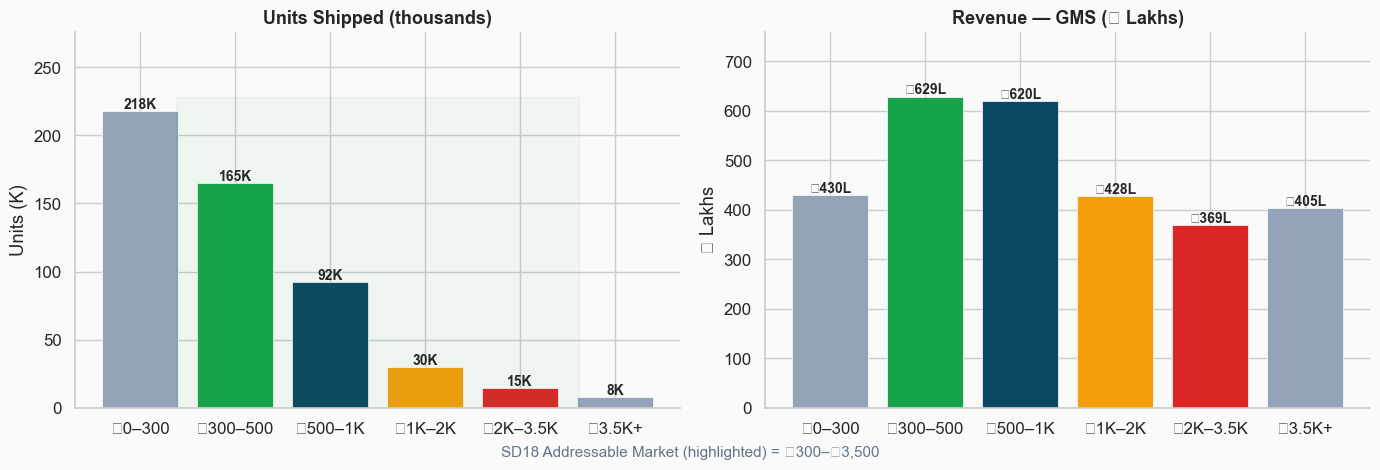

In [3]:
# Bar chart — units & revenue by price band with SD18 highlight
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_bar = ['#94a3b8', COLORS['green'], COLORS['navy'], COLORS['orange'], COLORS['red'], '#94a3b8']

# Units
ax = axes[0]
bars = ax.bar(band_data['price_band'], band_data['units'] / 1000, color=colors_bar, edgecolor='white', linewidth=0.5)
ax.set_title('Units Shipped (thousands)', fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Units (K)')
for bar, val in zip(bars, band_data['units']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val/1000:.0f}K',
            ha='center', fontsize=10, fontweight='bold')
ax.axhspan(0, ax.get_ylim()[1], xmin=1/6, xmax=5/6, alpha=0.05, color=COLORS['green'])
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# GMS
ax = axes[1]
bars = ax.bar(band_data['price_band'], band_data['gms_lakhs'], color=colors_bar, edgecolor='white', linewidth=0.5)
ax.set_title('Revenue — GMS (₹ Lakhs)', fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('₹ Lakhs')
for bar, val in zip(bars, band_data['gms_lakhs']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'₹{val:.0f}L',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('SD18 Addressable Market (highlighted) = ₹300–₹3,500', fontsize=11, color=COLORS['gray'], y=0.02)
plt.tight_layout()
plt.savefig('viz_price_bands.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Competition is Weak — Brand Landscape

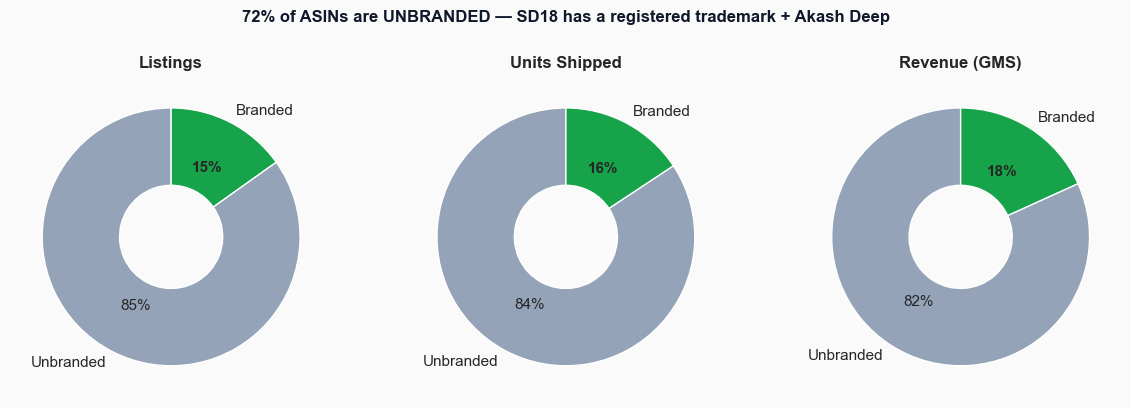

In [4]:
# Brand vs Unbranded split
branded = df[df['brand_clean'] != 'Unbranded']
unbranded = df[df['brand_clean'] == 'Unbranded']

split_data = pd.DataFrame({
    'Category': ['Unbranded', 'Branded'],
    'ASINs': [len(unbranded), len(branded)],
    'Units': [unbranded['units_shipped'].sum(), branded['units_shipped'].sum()],
    'GMS': [unbranded['gms'].sum(), branded['gms'].sum()]
})

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors_split = ['#94a3b8', COLORS['green']]

for i, (col, title) in enumerate([('ASINs', 'Listings'), ('Units', 'Units Shipped'), ('GMS', 'Revenue (GMS)')]):
    ax = axes[i]
    wedges, texts, autotexts = ax.pie(
        split_data[col], labels=split_data['Category'],
        colors=colors_split, autopct='%1.0f%%',
        textprops={'fontsize': 11}, startangle=90,
        wedgeprops=dict(width=0.6)
    )
    autotexts[1].set_fontweight('bold')
    ax.set_title(title, fontweight='bold', fontsize=12)

plt.suptitle('72% of ASINs are UNBRANDED — SD18 has a registered trademark + Akash Deep',
             fontsize=12, fontweight='bold', color=COLORS['dark'], y=1.02)
plt.tight_layout()
plt.savefig('viz_brand_split.png', dpi=150, bbox_inches='tight')
plt.show()

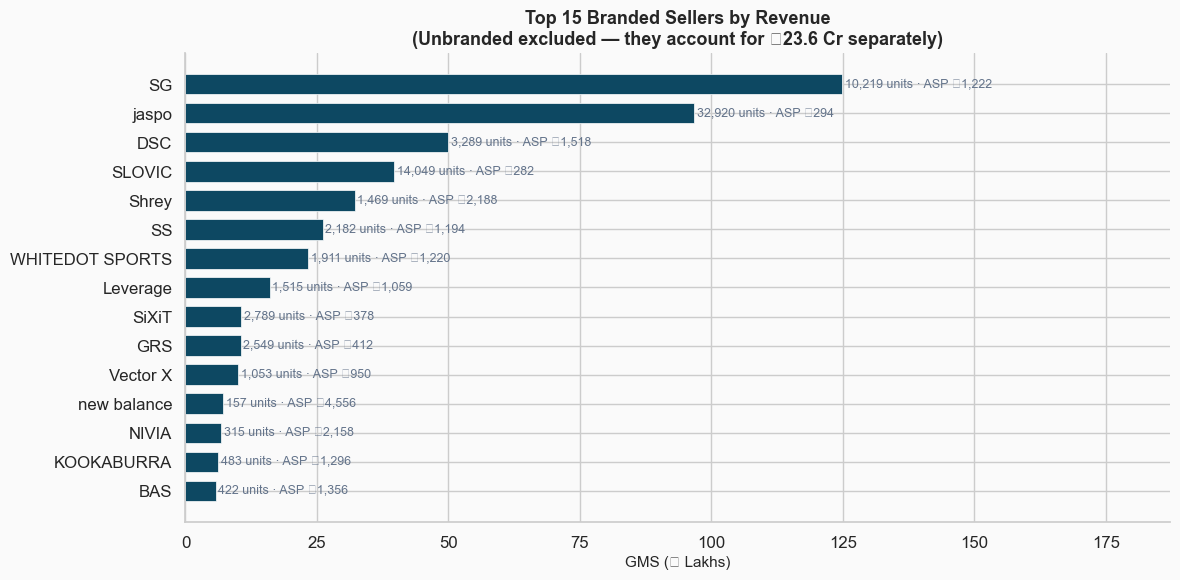

In [5]:
# Top 15 brands by GMS (excluding unbranded)
brand_agg = branded.groupby('brand_clean').agg(
    units=('units_shipped', 'sum'),
    gms=('gms', 'sum'),
    asins=('asin', 'count'),
    cp=('contribution_profit', 'sum')
).reset_index()
brand_agg['asp'] = brand_agg['gms'] / brand_agg['units']
brand_agg['cp_pct'] = brand_agg['cp'] / brand_agg['gms'] * 100
brand_agg['gms_lakhs'] = brand_agg['gms'] / 1e5
top15 = brand_agg.nlargest(15, 'gms')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top15['brand_clean'][::-1], top15['gms_lakhs'][::-1],
               color=COLORS['navy'], edgecolor='white', linewidth=0.5, height=0.7)

# Add unit count annotations
for bar, (_, row) in zip(bars, top15[::-1].iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{row["units"]:,.0f} units · ASP ₹{row["asp"]:,.0f}',
            va='center', fontsize=9, color=COLORS['gray'])

ax.set_xlabel('GMS (₹ Lakhs)', fontsize=11)
ax.set_title('Top 15 Branded Sellers by Revenue\n(Unbranded excluded — they account for ₹23.6 Cr separately)',
             fontweight='bold', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, top15['gms_lakhs'].max() * 1.5)

plt.tight_layout()
plt.savefig('viz_top_brands.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Sales Velocity — The Bar is Shockingly Low

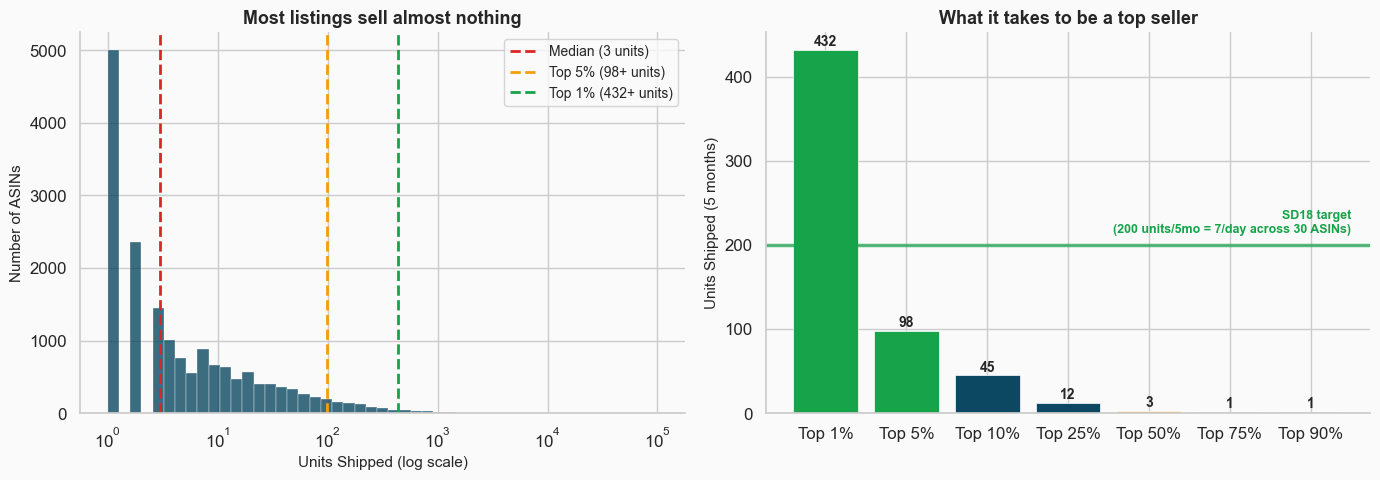


📊 Key stat: 12,661 out of 17,291 ASINs sell ≤10 units in 5 months (73%)


In [6]:
# Distribution of units shipped — log scale histogram
active = df[df['units_shipped'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram (log scale)
ax = axes[0]
ax.hist(active['units_shipped'], bins=np.logspace(0, 5, 50),
        color=COLORS['navy'], alpha=0.8, edgecolor='white', linewidth=0.3)
ax.set_xscale('log')
ax.axvline(3, color=COLORS['red'], linestyle='--', linewidth=2, label='Median (3 units)')
ax.axvline(98, color=COLORS['orange'], linestyle='--', linewidth=2, label='Top 5% (98+ units)')
ax.axvline(432, color=COLORS['green'], linestyle='--', linewidth=2, label='Top 1% (432+ units)')
ax.set_xlabel('Units Shipped (log scale)', fontsize=11)
ax.set_ylabel('Number of ASINs', fontsize=11)
ax.set_title('Most listings sell almost nothing', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: Percentile waterfall
ax = axes[1]
percentiles = [1, 5, 10, 25, 50, 75, 90]
thresholds = [np.percentile(active['units_shipped'], 100 - p) for p in percentiles]
labels_p = [f'Top {p}%' for p in percentiles]

bars = ax.bar(labels_p, thresholds, color=[COLORS['green'], COLORS['green'], COLORS['navy'],
              COLORS['navy'], COLORS['orange'], COLORS['gray'], COLORS['gray']],
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, thresholds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,.0f}', ha='center', fontsize=10, fontweight='bold')

# SD18 target line
ax.axhline(200, color=COLORS['green'], linestyle='-', linewidth=2.5, alpha=0.7)
ax.text(6.5, 215, 'SD18 target\n(200 units/5mo = 7/day across 30 ASINs)',
        fontsize=9, color=COLORS['green'], fontweight='bold', ha='right')

ax.set_ylabel('Units Shipped (5 months)', fontsize=11)
ax.set_title('What it takes to be a top seller', fontweight='bold', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz_velocity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Key stat: {(active["units_shipped"] <= 10).sum():,} out of {len(active):,} ASINs sell ≤10 units in 5 months ({(active["units_shipped"] <= 10).sum()/len(active)*100:.0f}%)')

## 4. SD18's Competitive Position — Scatter Analysis

In [7]:
# ASP vs Units scatter — SD18's sweet spot
plot_df = active[(active['asp'] > 50) & (active['asp'] < 5000) & (active['units_shipped'] >= 5)].copy()
plot_df['is_branded'] = plot_df['brand_clean'] != 'Unbranded'
plot_df['brand_label'] = plot_df['brand_clean'].where(plot_df['brand_clean'].isin(
    ['SG', 'DSC', 'SS', 'jaspo', 'SLOVIC', 'WHITEDOT SPORTS', 'Shrey', 'KOOKABURRA']
), 'Other')

fig = px.scatter(
    plot_df, x='asp', y='units_shipped',
    color='brand_label',
    size='gms', size_max=40,
    hover_data={'item_name': True, 'asp': ':.0f', 'units_shipped': ':,.0f', 'gms': ':,.0f'},
    log_y=True,
    color_discrete_map={
        'SG': '#dc2626', 'DSC': '#7c3aed', 'SS': '#0891b2',
        'jaspo': '#65a30d', 'SLOVIC': '#ca8a04', 'Other': '#cbd5e1',
        'WHITEDOT SPORTS': '#e11d48', 'Shrey': '#6366f1', 'KOOKABURRA': '#059669'
    },
    title='<b>Price vs Sales Volume</b> — Each dot is an ASIN (size = revenue)'
)

# SD18 zone
fig.add_vrect(x0=300, x1=3500, fillcolor=COLORS['green'], opacity=0.05,
              annotation_text='SD18 Price Range', annotation_position='top left')

fig.update_layout(
    xaxis_title='Average Selling Price (₹)',
    yaxis_title='Units Shipped (log scale)',
    height=550, width=950,
    legend_title='Brand'
)
fig.show()

## 5. Profitability Landscape — Where Amazon Pushes Traffic

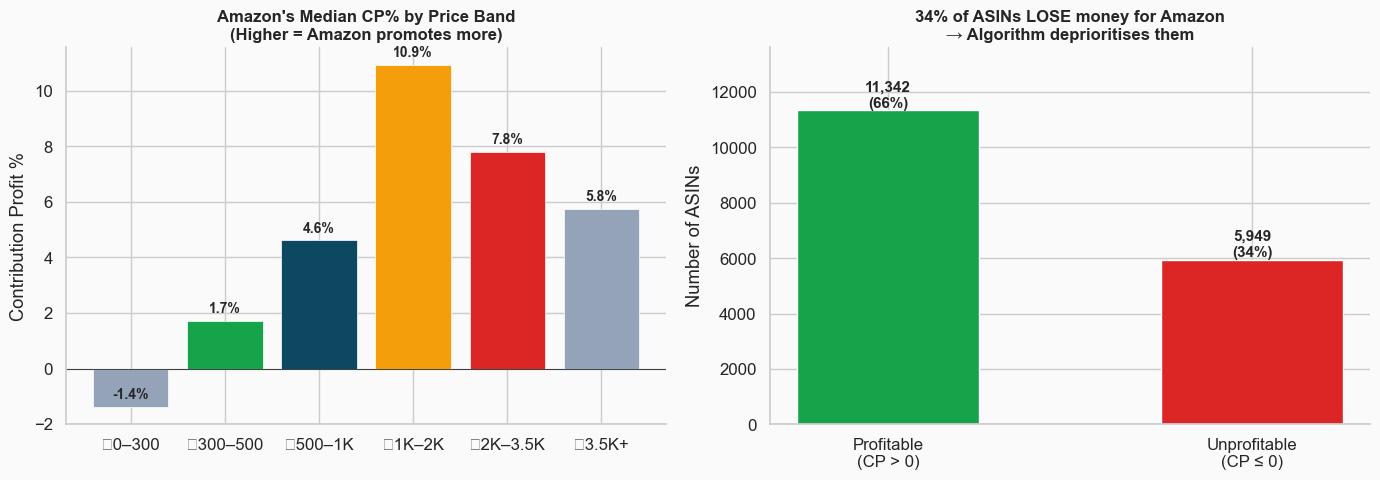

In [8]:
# CP% vs ASP — shows which price points Amazon WANTS to promote
cp_band = df[df['units_shipped'] >= 10].groupby('price_band', observed=True).agg(
    avg_cp_pct=('cp_pct', 'mean'),
    median_cp_pct=('cp_pct', 'median'),
    total_cp=('contribution_profit', 'sum'),
    count=('asin', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Profitability by price band
ax = axes[0]
bars = ax.bar(cp_band['price_band'], cp_band['median_cp_pct'],
              color=colors_bar, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Amazon\'s Median CP% by Price Band\n(Higher = Amazon promotes more)', fontweight='bold', fontsize=12)
ax.set_ylabel('Contribution Profit %')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, val in zip(bars, cp_band['median_cp_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Right: Profitable vs unprofitable
ax = axes[1]
profit_dist = pd.DataFrame({
    'Status': ['Profitable\n(CP > 0)', 'Unprofitable\n(CP ≤ 0)'],
    'Count': [(df['contribution_profit'] > 0).sum(), (df['contribution_profit'] <= 0).sum()]
})
bars = ax.bar(profit_dist['Status'], profit_dist['Count'],
              color=[COLORS['green'], COLORS['red']], edgecolor='white', width=0.5)
for bar, val in zip(bars, profit_dist['Count']):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}\n({pct:.0f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('34% of ASINs LOSE money for Amazon\n→ Algorithm deprioritises them', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of ASINs')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, profit_dist['Count'].max() * 1.2)

plt.tight_layout()
plt.savefig('viz_profitability.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. SD18 Direct Comparables — Balls & Bats

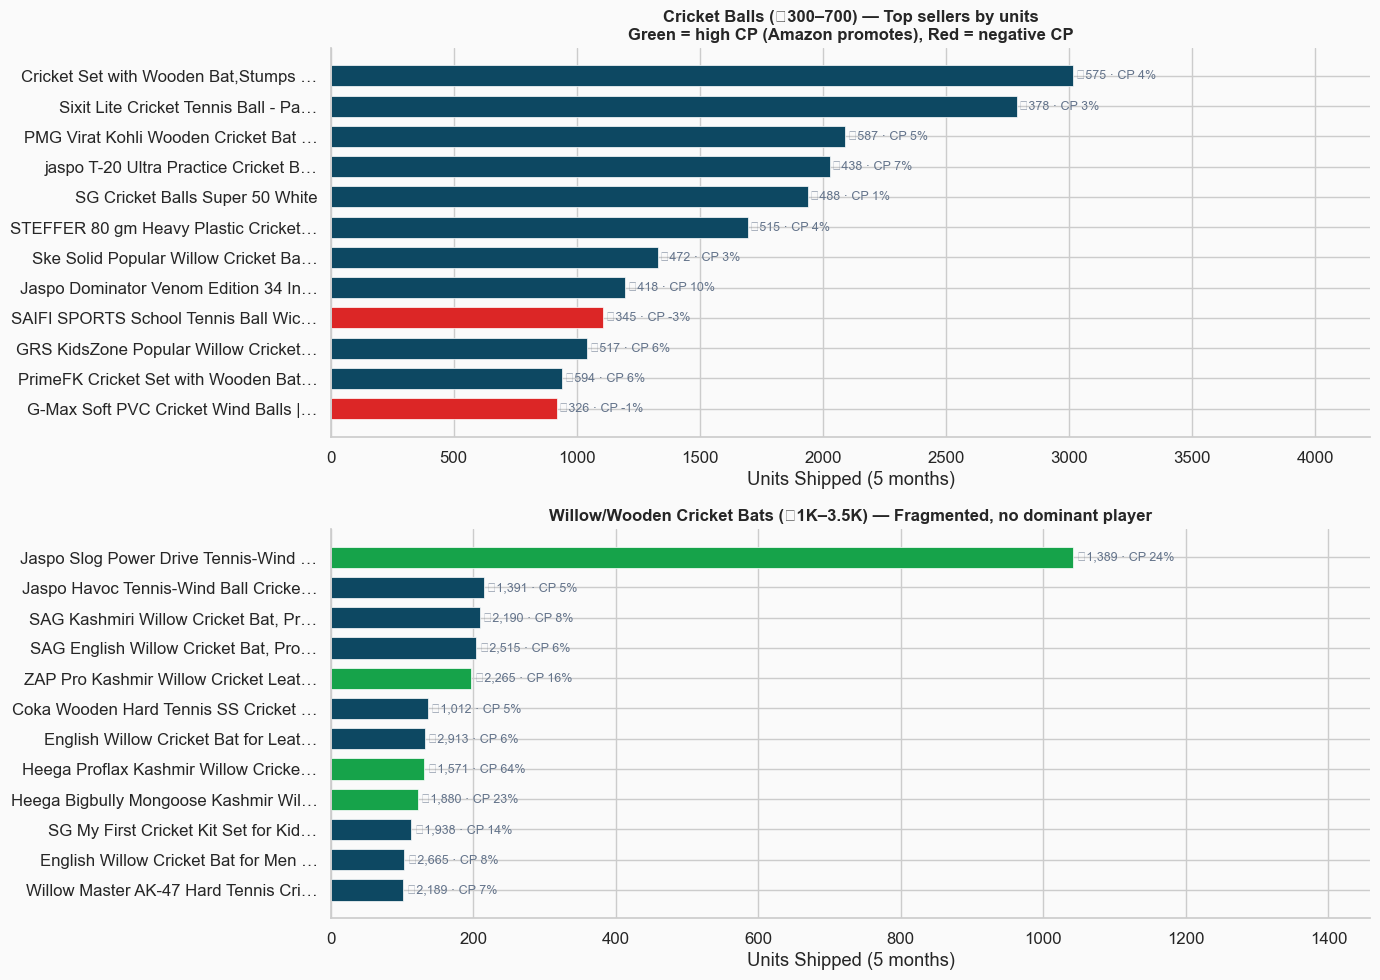

In [9]:
# Comparable products — balls and bats in SD18's range
balls = active[(active['item_name'].str.lower().str.contains('ball|cricket ball', na=False)) &
               (active['asp'] >= 300) & (active['asp'] <= 700) &
               (active['units_shipped'] >= 30)].nlargest(20, 'units_shipped').copy()

bats = active[(active['item_name'].str.lower().str.contains('bat', na=False)) &
              (active['item_name'].str.lower().str.contains('willow|wooden|wood', na=False)) &
              (active['asp'] >= 1000) & (active['asp'] <= 3500) &
              (active['units_shipped'] >= 15)].nlargest(20, 'units_shipped').copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Balls
ax = axes[0]
balls_plot = balls.head(12)
short_names = [n[:35] + '…' if len(n) > 35 else n for n in balls_plot['item_name']]
colors_b = [COLORS['green'] if cp > 10 else COLORS['navy'] if cp > 0 else COLORS['red']
            for cp in balls_plot['cp_pct']]
bars = ax.barh(short_names[::-1], balls_plot['units_shipped'][::-1],
               color=colors_b[::-1], edgecolor='white', linewidth=0.5, height=0.7)
for bar, (_, row) in zip(bars, balls_plot[::-1].iterrows()):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'₹{row["asp"]:,.0f} · CP {row["cp_pct"]:.0f}%',
            va='center', fontsize=9, color=COLORS['gray'])
ax.set_title('Cricket Balls (₹300–700) — Top sellers by units\nGreen = high CP (Amazon promotes), Red = negative CP',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Units Shipped (5 months)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, balls_plot['units_shipped'].max() * 1.4)

# Bats
ax = axes[1]
bats_plot = bats.head(12)
short_names = [n[:35] + '…' if len(n) > 35 else n for n in bats_plot['item_name']]
colors_bt = [COLORS['green'] if cp > 15 else COLORS['navy'] if cp > 0 else COLORS['red']
             for cp in bats_plot['cp_pct']]
bars = ax.barh(short_names[::-1], bats_plot['units_shipped'][::-1],
               color=colors_bt[::-1], edgecolor='white', linewidth=0.5, height=0.7)
for bar, (_, row) in zip(bars, bats_plot[::-1].iterrows()):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'₹{row["asp"]:,.0f} · CP {row["cp_pct"]:.0f}%',
            va='center', fontsize=9, color=COLORS['gray'])
ax.set_title('Willow/Wooden Cricket Bats (₹1K–3.5K) — Fragmented, no dominant player',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Units Shipped (5 months)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, bats_plot['units_shipped'].max() * 1.4)

plt.tight_layout()
plt.savefig('viz_comparables.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Market Share Required — SD18 Needs a Tiny Slice

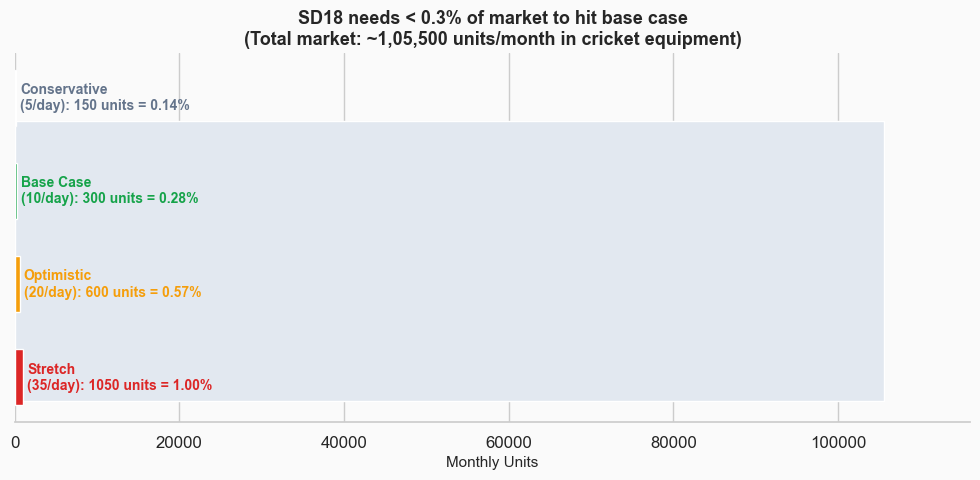

In [10]:
# Visual: SD18's target as fraction of total market
monthly_units = df['units_shipped'].sum() / 5
sd18_targets = {
    'Conservative\n(5/day)': 150,
    'Base Case\n(10/day)': 300,
    'Optimistic\n(20/day)': 600,
    'Stretch\n(35/day)': 1050
}

fig, ax = plt.subplots(figsize=(10, 5))

# Total market bar (background)
ax.barh(['Market'], [monthly_units], color='#e2e8f0', height=0.6, label=f'Total market ({monthly_units/1000:.0f}K units/mo)')

# SD18 targets
y_positions = [0.35, 0.15, -0.05, -0.25]
colors_t = [COLORS['gray'], COLORS['green'], COLORS['orange'], COLORS['red']]

for (label, units), y, color in zip(sd18_targets.items(), y_positions, colors_t):
    pct = units / monthly_units * 100
    ax.barh([y], [units], color=color, height=0.12)
    ax.text(units + 500, y, f'{label}: {units} units = {pct:.2f}%',
            va='center', fontsize=10, fontweight='bold', color=color)

ax.set_xlim(0, monthly_units * 1.1)
ax.set_yticks([])
ax.set_xlabel('Monthly Units', fontsize=11)
ax.set_title('SD18 needs < 0.3% of market to hit base case\n(Total market: ~1,05,500 units/month in cricket equipment)',
             fontweight='bold', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig('viz_market_share.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Revenue & Break-Even Model

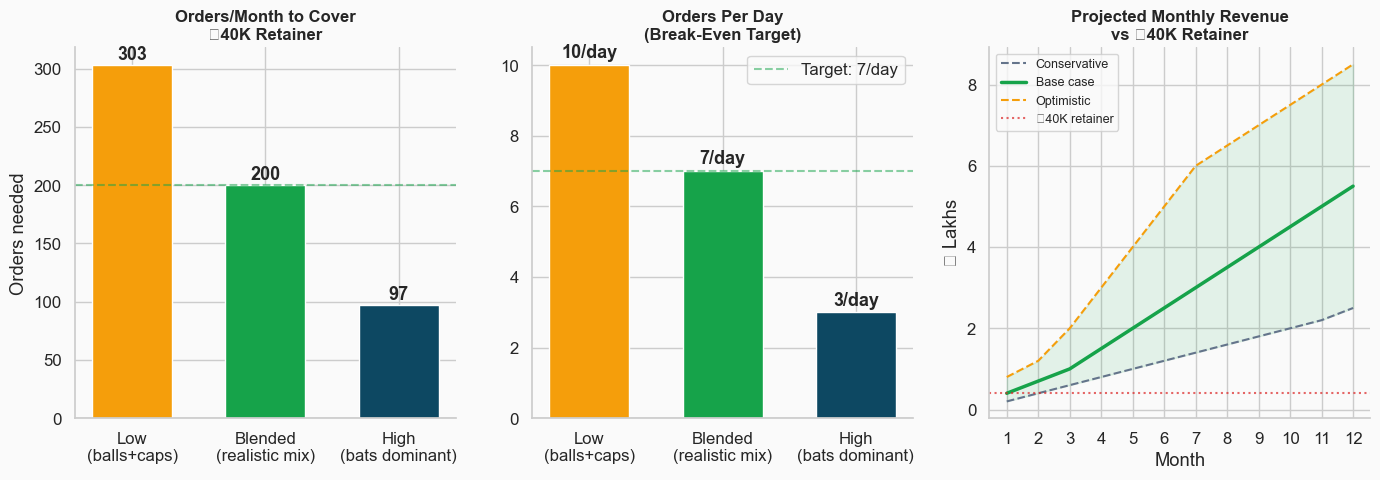

In [11]:
# Break-even visualization
scenarios = pd.DataFrame({
    'Scenario': ['Low\n(balls+caps)', 'Blended\n(realistic mix)', 'High\n(bats dominant)'],
    'ASP': [500, 800, 1800],
    'Net Margin': [0.26, 0.25, 0.23],
    'Net Per Order': [132, 200, 414],
    'Orders for 40K': [303, 200, 97],
    'Per Day': [10, 7, 3]
})

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Orders needed
ax = axes[0]
colors_s = [COLORS['orange'], COLORS['green'], COLORS['navy']]
bars = ax.bar(scenarios['Scenario'], scenarios['Orders for 40K'], color=colors_s, width=0.6)
for bar, val in zip(bars, scenarios['Orders for 40K']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}', ha='center', fontsize=13, fontweight='bold')
ax.axhline(200, color=COLORS['green'], linestyle='--', alpha=0.5)
ax.set_title('Orders/Month to Cover\n₹40K Retainer', fontweight='bold', fontsize=12)
ax.set_ylabel('Orders needed')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Per day
ax = axes[1]
bars = ax.bar(scenarios['Scenario'], scenarios['Per Day'], color=colors_s, width=0.6)
for bar, val in zip(bars, scenarios['Per Day']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val}/day', ha='center', fontsize=13, fontweight='bold')
ax.axhline(7, color=COLORS['green'], linestyle='--', alpha=0.5, label='Target: 7/day')
ax.set_title('Orders Per Day\n(Break-Even Target)', fontweight='bold', fontsize=12)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Revenue timeline projection
ax = axes[2]
months = np.arange(1, 13)
conservative = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 250]) * 1000
base = np.array([40, 70, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550]) * 1000
optimistic = np.array([80, 120, 200, 300, 400, 500, 600, 650, 700, 750, 800, 850]) * 1000

ax.fill_between(months, conservative/1e5, optimistic/1e5, alpha=0.1, color=COLORS['green'])
ax.plot(months, conservative/1e5, '--', color=COLORS['gray'], linewidth=1.5, label='Conservative')
ax.plot(months, base/1e5, '-', color=COLORS['green'], linewidth=2.5, label='Base case')
ax.plot(months, optimistic/1e5, '--', color=COLORS['orange'], linewidth=1.5, label='Optimistic')
ax.axhline(0.4, color=COLORS['red'], linestyle=':', linewidth=1.5, alpha=0.7, label='₹40K retainer')

ax.set_xlabel('Month')
ax.set_ylabel('₹ Lakhs')
ax.set_title('Projected Monthly Revenue\nvs ₹40K Retainer', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.set_xticks(months)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz_breakeven.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary Dashboard — One-Slide View

In [12]:
# Executive summary card
fig = go.Figure()

fig.add_trace(go.Indicator(
    mode='number', value=28.8,
    number={'suffix': ' Cr', 'font': {'size': 48, 'color': '#0f172a'}},
    title={'text': '<b>Category GMS</b><br><span style="font-size:12px;color:#64748b">Jan-May 2026</span>'},
    domain={'x': [0, 0.25], 'y': [0.55, 1]}
))

fig.add_trace(go.Indicator(
    mode='number', value=5.27,
    number={'suffix': 'L units', 'font': {'size': 48, 'color': '#0f172a'}},
    title={'text': '<b>Units Shipped</b><br><span style="font-size:12px;color:#64748b">5 months</span>'},
    domain={'x': [0.25, 0.5], 'y': [0.55, 1]}
))

fig.add_trace(go.Indicator(
    mode='number', value=72,
    number={'suffix': '%', 'font': {'size': 48, 'color': '#dc2626'}},
    title={'text': '<b>Unbranded ASINs</b><br><span style="font-size:12px;color:#64748b">Weak competition</span>'},
    domain={'x': [0.5, 0.75], 'y': [0.55, 1]}
))

fig.add_trace(go.Indicator(
    mode='number', value=3,
    number={'suffix': ' units', 'font': {'size': 48, 'color': '#f59e0b'}},
    title={'text': '<b>Median ASIN Sells</b><br><span style="font-size:12px;color:#64748b">Bar is incredibly low</span>'},
    domain={'x': [0.75, 1], 'y': [0.55, 1]}
))

fig.add_trace(go.Indicator(
    mode='number', value=71,
    number={'suffix': '%', 'font': {'size': 48, 'color': '#16a34a'}},
    title={'text': '<b>SD18 Range = Revenue</b><br><span style="font-size:12px;color:#64748b">₹300-₹3,500 captures 71% GMS</span>'},
    domain={'x': [0, 0.25], 'y': [0, 0.45]}
))

fig.add_trace(go.Indicator(
    mode='number', value=0.28,
    number={'suffix': '%', 'font': {'size': 48, 'color': '#16a34a'}},
    title={'text': '<b>Market Share Needed</b><br><span style="font-size:12px;color:#64748b">For base case (₹2L/mo)</span>'},
    domain={'x': [0.25, 0.5], 'y': [0, 0.45]}
))

fig.add_trace(go.Indicator(
    mode='number', value=7,
    number={'suffix': '/day', 'font': {'size': 48, 'color': '#16a34a'}},
    title={'text': '<b>Break-Even Orders</b><br><span style="font-size:12px;color:#64748b">Covers ₹40K retainer</span>'},
    domain={'x': [0.5, 0.75], 'y': [0, 0.45]}
))

fig.add_trace(go.Indicator(
    mode='number', value=34,
    number={'suffix': '%', 'font': {'size': 48, 'color': '#dc2626'}},
    title={'text': '<b>Sellers Losing Money</b><br><span style="font-size:12px;color:#64748b">SD18 won\'t be one of them</span>'},
    domain={'x': [0.75, 1], 'y': [0, 0.45]}
))

fig.update_layout(
    title='<b>Amazon India Cricket Equipment — Key Metrics for SD18</b>',
    title_font_size=18,
    height=500, width=1000,
    paper_bgcolor='#fafafa'
)
fig.show()

---
## Key Takeaways

1. **₹28.8 Crore market** in 5 months — SD18's price range captures 71% of it
2. **72% of competitors are unbranded** — SD18 + trademark + Akash Deep = unfair advantage
3. **Median ASIN sells 3 units.** SD18 targeting 7/day puts them in the **top 2%**
4. **No dominant player** in willow bats ₹1K–3.5K — wide open for SD18
5. **34% of sellers lose money** for Amazon — well-priced SD18 products get algorithmic preference
6. **SD18 needs 0.28% market share** for base case — not "beat SG", just "exist competently"

---
*Data: Amazon Internal Category Export | Period: Jan–May 2026 | Prepared by: Elevate Strategy*